In [1]:
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy   


In [ ]:
#Define QID - question matching
qids = ["V201324","V201416", "V202234", "V202257", "V202287", "V202332", "V202337", "V202348", "V202371", "V202378"]
name_dict = {"V201324" : "Current Economy", "V201416" : "Gay Marriage", "V202234" : "Refugee Allowing", 
            "V202257" : "Income Inequality", "V202287" : "Gender Role", "V202332": "Climate Change",
            "V202337": "Gun Regulation", "V202348": "Drug Addiction", "V202371": "Race Diversity", "V202378": "Health Insurance"}
qids_reverse_coded = ["V201416", "V202234", "V202257", "V202287", "V202332", "V202371"]

def get_counts(path, qids): #function to get a dict with counts for each question
    value_list = []

    for id in qids:
        df = pd.read_csv(path + id + ".csv")
        df['Response'] = pd.to_numeric(df['Response'], errors='coerce') 

        value_counts = Counter(df['Response'].dropna())

        if id in ["V201324", "V202332"]:
            answers = {i: value_counts[i] for i in range(1, 6)}
        else:
            answers = {i: value_counts[i] for i in range(1, 4)}

        value_list.append({name_dict[id]: answers})

    return value_list


In [5]:
# GPT4.1
# T=0
replicate_results_gpt41 = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_results/full_results_2020_", qids)
reformulated_results_gpt41 = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reform_results/full_results_2020_", qids)
priming_results_gpt41 = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_priming_results/full_results_2020_", qids)
preamble_results_gpt41 = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_preamble_results/full_results_2020_", qids)
reversed_results_gpt41 = get_counts("../Publication Results/Gpt4.1-Mini-Determinstic/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)

# llama8b
replicate_results_llama8b = get_counts("../Publication Results/8B-Llama/main_mq_results/full_results_2020_", qids)
reformulated_results_llama8b = get_counts("../Publication Results/8B-Llama/main_mq_reform_3rdP_results/full_results_2020_", qids)
priming_results_llama8b = get_counts("../Publication Results/8B-Llama/Priming/Original/full_results_2020_", qids)
preamble_results_llama8b = get_counts("../Publication Results/8B-Llama/Preamble/Original/full_results_2020_", qids)
reversed_results_llama8b = get_counts("../Publication Results/8B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)

# llama70b
replicate_results_llama70b = get_counts("../Publication Results/70B-Llama/main_mq_results/full_results_2020_", qids)
reformulated_results_llama70b = get_counts("../Publication Results/70B-Llama/main_mq_reform_results/full_results_2020_", qids)
priming_results_llama70b = get_counts("../Publication Results/70B-Llama/main_mq_priming_results/full_results_2020_", qids)
preamble_results_llama70b = get_counts("../Publication Results/70B-Llama/main_mq_preamble_results/full_results_2020_", qids)
reversed_results_llama70b = get_counts("../Publication Results/70B-Llama/main_mq_reverseV2_results/full_results_2020_", qids_reverse_coded)



In [6]:
from copy import deepcopy
def reverse_answers(rever_coded_V2_results):
    rever_coded_V2_results = {list(d.keys())[0]: list(d.values())[0] for d in rever_coded_V2_results}
    rever_coded_V2_results_copy = deepcopy(rever_coded_V2_results)

    rever_coded_V2_results["Gay Marriage"][1] = rever_coded_V2_results_copy["Gay Marriage"][3]
    rever_coded_V2_results["Gay Marriage"][3] = rever_coded_V2_results_copy["Gay Marriage"][1]

    rever_coded_V2_results["Refugee Allowing"][1] = rever_coded_V2_results_copy["Refugee Allowing"][2]
    rever_coded_V2_results["Refugee Allowing"][2] = rever_coded_V2_results_copy["Refugee Allowing"][1]

    rever_coded_V2_results["Income Inequality"][1] = rever_coded_V2_results_copy["Income Inequality"][2]
    rever_coded_V2_results["Income Inequality"][2] = rever_coded_V2_results_copy["Income Inequality"][1]

    rever_coded_V2_results["Gender Role"][1] = rever_coded_V2_results_copy["Gender Role"][2]
    rever_coded_V2_results["Gender Role"][2] = rever_coded_V2_results_copy["Gender Role"][1]

    rever_coded_V2_results["Climate Change"][1] = rever_coded_V2_results_copy["Climate Change"][5]
    rever_coded_V2_results["Climate Change"][2] = rever_coded_V2_results_copy["Climate Change"][4]
    rever_coded_V2_results["Climate Change"][4] = rever_coded_V2_results_copy["Climate Change"][2]
    rever_coded_V2_results["Climate Change"][5] = rever_coded_V2_results_copy["Climate Change"][1]

    rever_coded_V2_results["Race Diversity"][1] = rever_coded_V2_results_copy["Race Diversity"][2]
    rever_coded_V2_results["Race Diversity"][2] = rever_coded_V2_results_copy["Race Diversity"][1]

    rever_coded_V2_results = [{key: value} for key, value in rever_coded_V2_results.items()]
    return rever_coded_V2_results

reversed_results_llama8b = reverse_answers(reversed_results_llama8b)
reversed_results_llama70b = reverse_answers(reversed_results_llama70b)
reversed_results_gpt41 = reverse_answers(reversed_results_gpt41)

In [8]:
def get_human_counts(path, qids): #getting results from anes 2020
     anes_df = pd.read_csv(path)
     human_values = []

     for id in qids:
          human_counts = Counter(anes_df[id].dropna())

          if id in ["V201324", "V202332"]:
               answers = {i: human_counts[i] for i in range(1, 6)}
          else:
               answers = {i: human_counts[i] for i in range(1, 4)}

          human_values.append({name_dict[id]: answers})

     return human_values

human_results = get_human_counts("../data/2020 ANES_test.csv", qids)

/var/folders/8s/b_t8p6s52r9c8k1j22zs0l740000gn/T/ipykernel_20182/955040501.py:2: DtypeWarning: Columns (19,21,22,23,25,26,27,29,30,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  anes_df = pd.read_csv(path)


In [9]:
#JSD divergence is a more numerically stable version of KL-divergence - better for our case
def jsd_divergence_between_sets(set1, set2, base=2):

    jsd_results = {}

    dict1 = {list(d.keys())[0]: list(d.values())[0] for d in set1}
    dict2 = {list(d.keys())[0]: list(d.values())[0] for d in set2}

    for question in dict1.keys():
        if question not in dict2:
            continue 

        p_counts = dict1[question]
        q_counts = dict2[question]

        p = np.array([p_counts.get(k, 0) for k in p_counts], dtype=float)
        q = np.array([q_counts.get(k, 0) for k in p_counts], dtype=float)

        p /= p.sum()
        q /= q.sum()

        epsilon = 1e-10
        p = np.clip(p, epsilon, 1)
        q = np.clip(q, epsilon, 1)

        m = 0.5 * (p + q)
        jsd_pq = 0.5 * (entropy(p, m, base=base) + entropy(q, m, base=base)) 
        jsd_results[question] = jsd_pq

    return jsd_results


In [10]:
# GPT4.1
jsd_results_replicate_gpt41 = jsd_divergence_between_sets(human_results, replicate_results_gpt41, base=2)
jsd_results_reformulated_gpt41 = jsd_divergence_between_sets(human_results, reformulated_results_gpt41, base=2)
jsd_results_priming_gpt41 = jsd_divergence_between_sets(human_results, priming_results_gpt41, base = 2)
jsd_results_preamble_gpt41 = jsd_divergence_between_sets(human_results, preamble_results_gpt41, base = 2)
jsd_results_reversed_gpt41 = jsd_divergence_between_sets(human_results, reversed_results_gpt41, base = 2)

diff_reformulated_vs_replicate_gpt41 = {key: (jsd_results_reformulated_gpt41[key] - jsd_results_replicate_gpt41[key]) for key in jsd_results_replicate_gpt41.keys()}
diff_priming_vs_replicate_gpt41 = {key: (jsd_results_priming_gpt41[key] - jsd_results_replicate_gpt41[key]) for key in jsd_results_replicate_gpt41.keys()}
diff_preamble_vs_replicate_gpt41 = {key: (jsd_results_preamble_gpt41[key] - jsd_results_replicate_gpt41[key]) for key in jsd_results_replicate_gpt41.keys()}
diff_reversed_vs_replicate_gpt41 = {key: (jsd_results_reversed_gpt41[key] - jsd_results_replicate_gpt41[key]) for key in jsd_results_reversed_gpt41.keys()}


# LLama8b
jsd_results_replicate_llama8b = jsd_divergence_between_sets(human_results, replicate_results_llama8b, base=2)
jsd_results_reformulated_llama8b = jsd_divergence_between_sets(human_results, reformulated_results_llama8b, base=2)
jsd_results_priming_llama8b = jsd_divergence_between_sets(human_results, priming_results_llama8b, base = 2)
jsd_results_preamble_llama8b = jsd_divergence_between_sets(human_results, preamble_results_llama8b, base = 2)
jsd_results_reversed_llama8b = jsd_divergence_between_sets(human_results, reversed_results_llama8b, base = 2)

diff_reformulated_vs_replicate_llama8b = {key: (jsd_results_reformulated_llama8b[key] - jsd_results_replicate_llama8b[key]) for key in jsd_results_replicate_llama8b.keys()}
diff_priming_vs_replicate_llama8b = {key: (jsd_results_priming_llama8b[key] - jsd_results_replicate_llama8b[key]) for key in jsd_results_replicate_llama8b.keys()}
diff_preamble_vs_replicate_llama8b = {key: (jsd_results_preamble_llama8b[key] - jsd_results_replicate_llama8b[key]) for key in jsd_results_replicate_llama8b.keys()}
diff_reversed_vs_replicate_llama8b = {key: (jsd_results_reversed_llama8b[key] - jsd_results_replicate_llama8b[key]) for key in jsd_results_reversed_llama8b.keys()}


# Llama70b
jsd_results_replicate_llama70b = jsd_divergence_between_sets(human_results, replicate_results_llama70b, base=2)
jsd_results_reformulated_llama70b = jsd_divergence_between_sets(human_results, reformulated_results_llama70b, base=2)
jsd_results_priming_llama70b = jsd_divergence_between_sets(human_results, priming_results_llama70b, base = 2)
jsd_results_preamble_llama70b = jsd_divergence_between_sets(human_results, preamble_results_llama70b, base = 2)
jsd_results_reversed_llama70b = jsd_divergence_between_sets(human_results, reversed_results_llama70b, base = 2)

diff_reformulated_vs_replicate_llama70b = {key: (jsd_results_reformulated_llama70b[key] - jsd_results_replicate_llama70b[key]) for key in jsd_results_replicate_llama70b.keys()}
diff_priming_vs_replicate_llama70b = {key: (jsd_results_priming_llama70b[key] - jsd_results_replicate_llama70b[key]) for key in jsd_results_replicate_llama70b.keys()}
diff_preamble_vs_replicate_llama70b = {key: (jsd_results_preamble_llama70b[key] - jsd_results_replicate_llama70b[key]) for key in jsd_results_replicate_llama70b.keys()}
diff_reversed_vs_replicate_llama70b = {key: (jsd_results_reversed_llama70b[key] - jsd_results_replicate_llama70b[key]) for key in jsd_results_reversed_llama70b.keys()}



In [11]:
def plot_diff_JSD_by_condition(jsd_results1, jsd_results2, jsd_results3, label1, label2, label3, output_path='',title=''):

    categories = [
        'Climate Change', 'Current Economy', 'Refugee Allowing', 'Health Insurance',
        'Income Inequality', 'Race Diversity', 'Drug Addiction',
        'Gay Marriage', 'Gun Regulation', 'Gender Role'
    ]
   
    x = np.arange(len(categories))

    model_colors = [
    (0.12, 0.47, 0.71, 1.0), # Strongest (Blue)
    (0.20, 0.63, 0.17, 1.0), # Medium-Strong (Green)
    (0.96, 0.73, 0.07, 1.0), # Neutral (Yellow/Gold)
    (1.0, 0.50, 0.0, 1.0),   # Medium-Weak (Orange)
    (0.78, 0.24, 0.24, 1.0)  # Weakest (Red)
    ]
    model_colors = [
    (0.0, 0.30, 0.60, 1.0),   # Dark Blue
    (0.0, 0.50, 0.0, 1.0),    # Forest Green
    (0.85, 0.65, 0.0, 1.0),   # Mustard Yellow
    (0.9, 0.40, 0.0, 1.0),    # Dark Orange
    (0.65, 0.0, 0.0, 1.0)     # Crimson Red
]
    jsd1 = []
    jsd2 = []
    jsd3 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])
        jsd3.append(jsd_results3[question])

    fig, ax1 = plt.subplots(figsize=(6.4, 4))
 
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=30, ha='center')
    linewidth_value = 1.4
    markeredgewidth_value = 1.4
    ax1.plot(
        x-0.1, jsd1,
        color=model_colors[0], marker='^', markerfacecolor='none',
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value,linestyle='-',
    )
    ax1.plot(
        x, jsd2,
        color=model_colors[1], marker='^', markerfacecolor='none',
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value,
    )
    ax1.plot(
        x+0.1, jsd3,
        color=model_colors[3], marker='^', markerfacecolor='none',  
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value,
    )
    if 'Reformulated' in title:
        is_significant_1= np.array([True, True, True, True, True, True, True, True, True, True])
        jsd1_sig = np.where(is_significant_1, jsd1, np.nan)

        is_significant_2= np.array([True, True, True, False, False, True, True, True, True, True])
        jsd2_sig = np.where(is_significant_2, jsd2, np.nan)

        is_significant_3= np.array([True, True, True, True, True, True, True, True, True, True])
        jsd3_sig = np.where(is_significant_3, jsd3, np.nan)

    elif 'Priming' in title:
        is_significant_1= np.array([False, True, False, False, True, True, False, True, True, True])
        jsd1_sig = np.where(is_significant_1, jsd1, np.nan)

        is_significant_2= np.array([True, True, True, False, False, False, False, False, True, True])
        jsd2_sig = np.where(is_significant_2, jsd2, np.nan)

        is_significant_3= np.array([True, True, False, True, True, True, True, True, True, True])
        jsd3_sig = np.where(is_significant_3, jsd3, np.nan)
        
    elif 'Preamble' in title:
        is_significant_1= np.array([False, True, True, False, True, True, True, True, True, True])
        jsd1_sig = np.where(is_significant_1, jsd1, np.nan)

        is_significant_2= np.array([True, True, False, False, False, True, False, False, True, True])
        jsd2_sig = np.where(is_significant_2, jsd2, np.nan)

        is_significant_3= np.array([True, False, True, True, True, False, True, True, True, True])
        jsd3_sig = np.where(is_significant_3, jsd3, np.nan)
    
    # mark significance
    ax1.plot(
        x-0.1, jsd1_sig,
        color=model_colors[0], marker='^', 
        markerfacecolor=model_colors[0], # Fills the significant marker
        markersize=10, linewidth=linewidth_value,  
        markeredgewidth=markeredgewidth_value, 
        label=f'{label1}'
    )

    ax1.plot(
        x, jsd2_sig,
        color=model_colors[1], marker='^', 
        markerfacecolor=model_colors[1], # Fills the significant marker
        markersize=10, linewidth=linewidth_value, 
        markeredgewidth=markeredgewidth_value, 
        label=f'{label2}'
    )

    ax1.plot(
        x+0.1, jsd3_sig,
        color=model_colors[3], marker='^', 
        markerfacecolor=model_colors[3], # Fills the significant marker
        markersize=10, linewidth=linewidth_value, 
        markeredgewidth=markeredgewidth_value, 
        label=f'{label3}'
    )

    ax1.axhline(y=0, color='k', linestyle='--', linewidth=1)#, label='y=0 Line')
    ax1.set_title(r'$\Delta$ '+title)
    ax1.set_ylabel(r'$\Delta$ JS-divergence')
    ax1.set_ylim(-0.24, 0.4)

    ax1.set_xmargin(0.02)

    # --- JSD legend ---
    ax1.legend(loc='upper center', frameon=False, ncol=2)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(True)
    ax1.spines['right'].set_visible(True)
    ax1.spines['bottom'].set_visible(True)   # optional
    ax1.spines['left'].set_visible(True)     # optional
 
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")



Saved figure to ../plots/reformulated-jsd-diff.pdf
Saved figure to ../plots/priming-jsd-diff.pdf
Saved figure to ../plots/preamble-jsd-diff.pdf


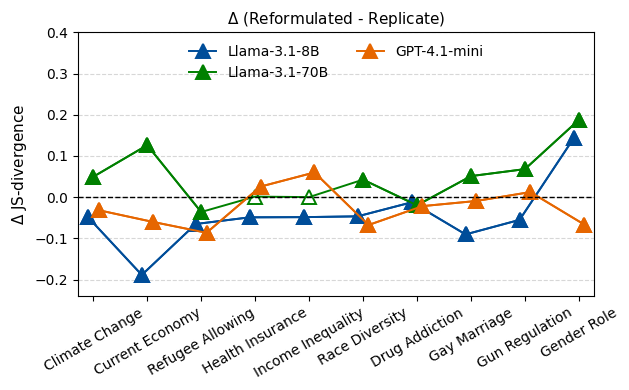

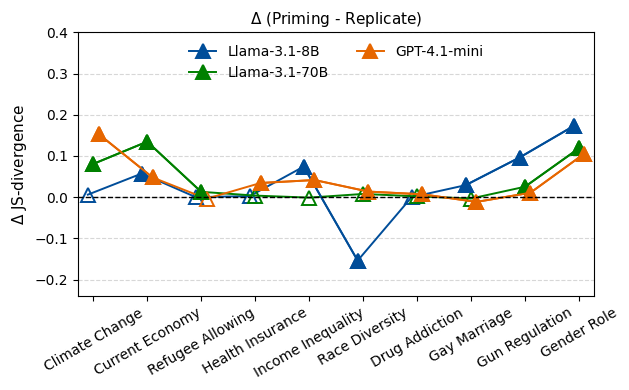

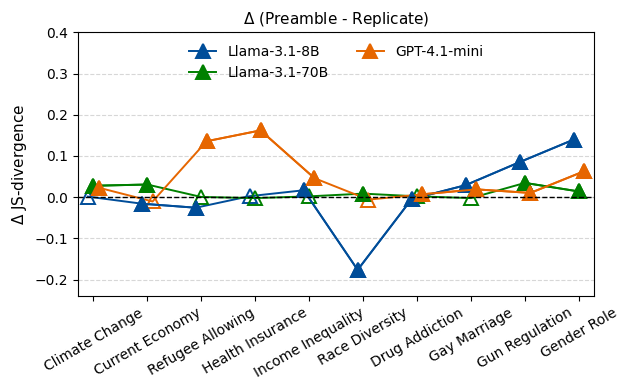

In [14]:

plot_diff_JSD_by_condition(diff_reformulated_vs_replicate_llama8b, diff_reformulated_vs_replicate_llama70b, diff_reformulated_vs_replicate_gpt41,
                           'Llama-3.1-8B', 'Llama-3.1-70B', "GPT-4.1-mini", '../plots/reformulated-jsd-diff.pdf', '(Reformulated - Replicate)')

plot_diff_JSD_by_condition(diff_priming_vs_replicate_llama8b, diff_priming_vs_replicate_llama70b, diff_priming_vs_replicate_gpt41,
                           'Llama-3.1-8B', 'Llama-3.1-70B', "GPT-4.1-mini", '../plots/priming-jsd-diff.pdf', '(Priming - Replicate)')

plot_diff_JSD_by_condition(diff_preamble_vs_replicate_llama8b, diff_preamble_vs_replicate_llama70b, diff_preamble_vs_replicate_gpt41,
                           'Llama-3.1-8B', 'Llama-3.1-70B', "GPT-4.1-mini", '../plots/preamble-jsd-diff.pdf', '(Preamble - Replicate)')

In [16]:
def plot_diff_JSD_by_condition_reversed(jsd_results1, jsd_results2, jsd_results3, 
label1, label2, label3, output_path='',title=''):

    categories = [
    'Climate Change', 'Refugee Allowing', 
    'Income Inequality', 'Race Diversity', 
    'Gay Marriage', 'Gender Role'
    ]
    x = np.arange(len(categories))

    model_colors = [
    (0.12, 0.47, 0.71, 1.0), # Strongest (Blue)
    (0.20, 0.63, 0.17, 1.0), # Medium-Strong (Green)
    (0.96, 0.73, 0.07, 1.0), # Neutral (Yellow/Gold)
    (1.0, 0.50, 0.0, 1.0),   # Medium-Weak (Orange)
    (0.78, 0.24, 0.24, 1.0)  # Weakest (Red)
    ]
    model_colors = [
    (0.0, 0.30, 0.60, 1.0),   # Dark Blue
    (0.0, 0.50, 0.0, 1.0),    # Forest Green
    (0.85, 0.65, 0.0, 1.0),   # Mustard Yellow
    (0.9, 0.40, 0.0, 1.0),    # Dark Orange
    (0.65, 0.0, 0.0, 1.0)     # Crimson Red
]
    jsd1 = []
    jsd2 = []
    jsd3 = []

    # --- Build stacked distributions for each category ---
    for question in categories:
        jsd1.append(jsd_results1[question])
        jsd2.append(jsd_results2[question])
        jsd3.append(jsd_results3[question])

    fig, ax1 = plt.subplots(figsize=(5.6, 4.))
 
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=30, ha='center')
    linewidth_value = 1.4
    markeredgewidth_value = 1.4
    ax1.plot(
        x-0.1, jsd1,
        color=model_colors[0], marker='^', markerfacecolor=model_colors[0],
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value,linestyle='-',
        label=f'{label1}'
    )
    ax1.plot(
        x, jsd2,
        color=model_colors[1], marker='^', markerfacecolor='none',
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value
    )
    ax1.plot(
        x+0.1, jsd3,
        color=model_colors[3], marker='^', markerfacecolor=model_colors[3],  
        markersize=10, linewidth=linewidth_value, markeredgewidth=markeredgewidth_value,
        label=f'{label3}'
    )
    # mark significance
    is_significant_2= np.array([True, True, False, True, True, True])
    jsd2_sig = np.where(is_significant_2, jsd2, np.nan)

    ax1.plot(
        x, jsd2_sig,
        color=model_colors[1], marker='^', 
        markerfacecolor=model_colors[1], # Fills the significant marker
        markersize=10, linewidth=linewidth_value,  
        markeredgewidth=markeredgewidth_value, 
        label=f'{label2}'
    )
    
    ax1.axhline(y=0, color='k', linestyle='--', linewidth=1)#, label='y=0 Line')
    ax1.set_title(r'$\Delta$ '+title)
    ax1.set_ylabel(r'$\Delta$ JS-divergence')
    ax1.set_ylim(-0.24, 0.9)

    ax1.set_xmargin(0.02)

    # --- JSD legend ---
    ax1.legend(loc='upper center', frameon=False, ncol=2)
    plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
    # --- Remove figure box / spines ---
    ax1.spines['top'].set_visible(True)
    ax1.spines['right'].set_visible(True)
    ax1.spines['bottom'].set_visible(True)   # optional
    ax1.spines['left'].set_visible(True)     # optional
 
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    fig.tight_layout()

    if output_path != '':
        fig.savefig(
            output_path,
            format="pdf",
            bbox_inches="tight",     # removes extra margins
            pad_inches=0.05,         # small padding
            dpi=300                  # high quality
        )
        print(f"Saved figure to {output_path}")



Saved figure to ../plots/reversed-jsd-diff.pdf


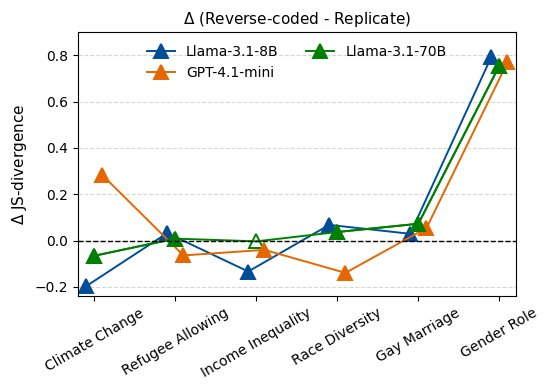

In [17]:
plot_diff_JSD_by_condition_reversed(diff_reversed_vs_replicate_llama8b, diff_reversed_vs_replicate_llama70b, diff_reversed_vs_replicate_gpt41,
                           'Llama-3.1-8B', 'Llama-3.1-70B', "GPT-4.1-mini", '../plots/reversed-jsd-diff.pdf', '(Reverse-coded - Replicate)')